In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [44]:
# See the data and shape, remove residual index column
# No NAs

sales = pd.read_csv("./training.csv")
sales= sales.iloc[:,1:]
print("Shape: ",sales.shape)
print("NA values", len(sales[sales.isna().any(axis=1)]))
sales.head()

Shape:  (640840, 9)
NA values 0


,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,366,4,2013-04-18,517,1,0,0,0,4422
1,394,6,2015-04-11,694,1,0,0,0,8297
2,807,4,2013-08-29,970,1,1,0,0,9729
3,802,2,2013-05-28,473,1,1,0,0,6513
4,726,4,2013-10-10,1068,1,1,0,0,10882


In [45]:
# Sanity check -> no sales on closed days
sales['sales'][sales['open']==0].sum()

np.int64(0)

In [46]:
# Mapping all non-zero state holiday to 1
print(sales['state_holiday'].value_counts())
sales['state_holiday'] = sales['state_holiday'].apply(lambda x: 0 if str(x) == '0' else 1)


state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64


In [47]:
# Create year and month and describe data
sales["date"] = pd.to_datetime(sales["date"])
sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month
sales.drop(columns='date', inplace=True)

sales.describe()
# day_of_week: categorical
# open: boolean
# promotion: boolean
# school_holiday: boolean
# year: spans from 2013-2015
# nb_customers_on_day: numerical

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.00000,640840.000000,640840.000000,640840.000000,640840.000000
mean,558.211348,4.000189,633.398577,0.830185,0.381718,0.03071,0.178472,5777.469011,2013.832351,5.846555
std,321.878521,1.996478,464.094416,0.375470,0.485808,0.17253,0.382910,3851.338083,0.777335,3.326202
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2013.000000,1.000000
25%,280.000000,2.000000,405.000000,1.000000,0.000000,0.00000,0.000000,3731.000000,2013.000000,3.000000
50%,558.000000,4.000000,609.000000,1.000000,0.000000,0.00000,0.000000,5746.000000,2014.000000,6.000000
75%,837.000000,6.000000,838.000000,1.000000,1.000000,0.00000,0.000000,7860.000000,2014.000000,8.000000
max,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.00000,1.000000,41551.000000,2015.000000,12.000000


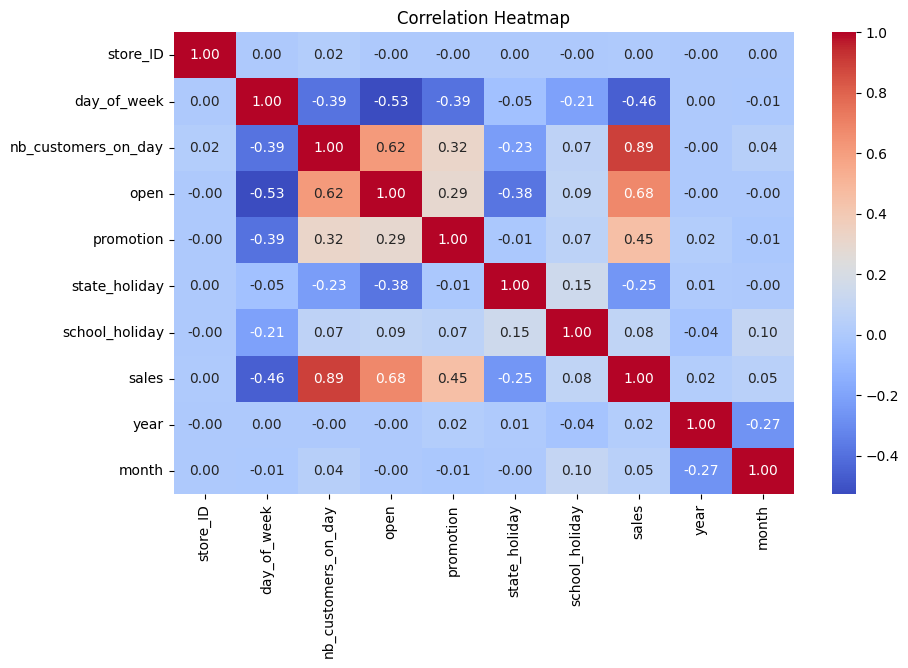

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # small heatmap
sns.heatmap(sales.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

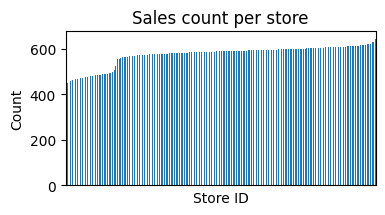

In [49]:
# For each store we have at least 400+ days of data
sales['store_ID'].value_counts(ascending=True).plot(kind='bar', figsize=(4,2))
plt.xlabel('Store ID')
plt.ylabel('Count')
plt.title('Sales count per store')
plt.xticks([])
plt.show()

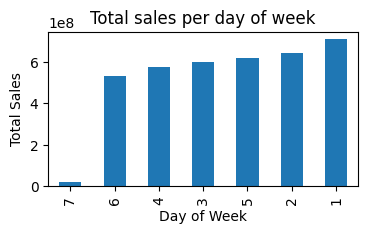

In [50]:
sales.groupby('day_of_week')['sales'].sum().sort_values(ascending=True).plot(
    kind='bar',
    figsize=(4,2)
)
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.title('Total sales per day of week')
plt.show()

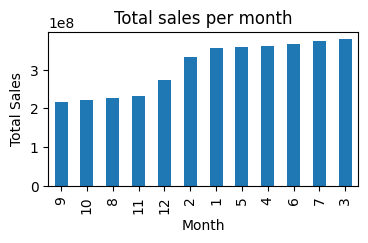

In [51]:
sales.groupby('month')['sales'].sum().sort_values(ascending=True).plot(
    kind='bar',
    figsize=(4,2)
)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Total sales per month')
plt.show()

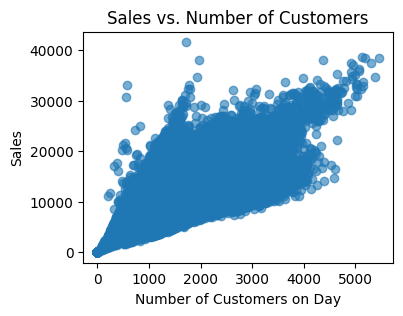

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
plt.scatter(sales['nb_customers_on_day'], sales['sales'], alpha=0.6)
plt.xlabel('Number of Customers on Day')
plt.ylabel('Sales')
plt.title('Sales vs. Number of Customers')
plt.show()

## MODEL

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

In [54]:
sales.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month
0,366,4,517,1,0,0,0,4422,2013,4
1,394,6,694,1,0,0,0,8297,2015,4
2,807,4,970,1,1,0,0,9729,2013,8
3,802,2,473,1,1,0,0,6513,2013,5
4,726,4,1068,1,1,0,0,10882,2013,10


In [70]:
# Basic LR model inclusong ONLY variables that correlate with sales
X_lin = sales[['day_of_week','nb_customers_on_day', 'open', 'promotion', 'state_holiday']]
y_lin = sales[['sales']]
model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_lin, y_lin, cv=cv, scoring='r2')

print("R² scores:", scores)
print("Mean R²:", np.mean(scores))

R² scores: [0.85080833 0.85339139 0.8550551  0.85322354 0.85227959]
Mean R²: 0.8529515903719129


In [ ]:
# LR Model - including Day of week and Months
sales2 = sales.copy()
sales2 = pd.get_dummies(sales2, columns=['day_of_week']).astype(int)
sales2 = pd.get_dummies(sales2, columns=['month']).astype(int)
sales2 = pd.get_dummies(sales2, columns=['year']).astype(int)

X_lin = sales2.drop(columns=['store_ID','day_of_week_1', 'month_12', 'year_2015', 'sales' ])
y_lin = sales2[['sales']]
model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_lin, y_lin, cv=cv, scoring='r2')

print("R² scores:", scores)
print("Mean R²:", np.mean(scores))


R² scores: [0.85874528 0.86181079 0.86295165 0.86111557 0.86065207]
Mean R²: 0.8610550727456214


In [ ]:
# LR - Using the Target encoder on the Store ID

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from category_encoders import TargetEncoder

X = sales2.drop(columns=['day_of_week_1', 'month_12', 'year_2015',  'sales' ])
y = sales2['sales']

encoder = TargetEncoder(cols=['store_ID'])
model = LinearRegression()

pipe = make_pipeline(encoder, model)

# 5-fold cross-validation using R² (you can also use neg_mean_squared_error)
scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')

print("CV R² scores:", scores)
print("Mean R²:", scores.mean())

CV R² scores: [0.89083018 0.88981718 0.88747852 0.88929542 0.88776831]
Mean R²: 0.889037920602122


In [ ]:
# LR - Using the storeID as a Dummy variable
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score

def adjusted_r2(y_true, y_pred, X):
    """Compute adjusted R²."""
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X.shape[1]
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

sales3 = pd.get_dummies(sales2, columns=['store_ID']).astype(int)

# Define adjusted R² function


# Your setup
X_lin = sales3.drop(columns=['day_of_week_1', 'month_12', 'year_2015', 'store_ID_1115', 'sales'])
y_lin = sales3[['sales']]

model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predictions
y_pred = cross_val_predict(model, X_lin, y_lin, cv=cv)

r2 = r2_score(y_lin, y_pred)
r2_adj = adjusted_r2(y_lin, y_pred, X_lin)

print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {r2_adj:.4f}")


R²: 0.9576
Adjusted R²: 0.9575


In [ ]:
# XGBOOST

import os
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

df = sales.copy()

# Encode categorical columns
for col in ['store_ID', 'day_of_week', 'year', 'month']:
    
    df[col] = LabelEncoder().fit_transform(df[col])

X = df[['store_ID', 'day_of_week', 'nb_customers_on_day', 'open', 'promotion',
       'state_holiday', 'school_holiday', 'year', 'month']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost with categorical awareness
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    enable_categorical=True,  
    tree_method='hist',      
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))


R²: 0.9313978552818298


# Real Data Predictions

In [124]:
# XGBOOST

real_data = pd.read_csv("./REAL_DATA.csv")
real_data['state_holiday'] = real_data['state_holiday'].apply(lambda x: 0 if str(x) == '0' else 1)

real_data["date"] = pd.to_datetime(real_data["date"], dayfirst=True)
real_data["year"] = real_data["date"].dt.year
real_data["month"] = real_data["date"].dt.month
real_data.drop(columns='date', inplace=True)
real_data.drop(columns='index', inplace=True)

y_pred_real = xgb_model.predict(real_data)
y_pred_real_clipped = np.clip(y_pred_real, 0, None)
y_pred_real_clipped

array([  54.924526,    0.      , 6815.0957  , ..., 5657.0293  ,
       6876.5405  , 8906.77    ], shape=(71205,), dtype=float32)

In [126]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_lin, y_lin)

real2 = real_data.copy()
real2 = pd.get_dummies(real2, columns=['day_of_week']).astype(int)
real2 = pd.get_dummies(real2, columns=['month']).astype(int)
real2 = pd.get_dummies(real2, columns=['year']).astype(int)
real2 = pd.get_dummies(real2, columns=['store_ID']).astype(int)

real2 = real2.drop(columns=['day_of_week_1', 'month_12', 'year_2015', 'store_ID_1115'])

lr_real_pred = lr_model.predict(real2)
lr_pred_real_clipped = np.clip(lr_real_pred, 0, None)
lr_pred_real_clipped


array([[1050.45848083],
       [ 466.01658661],
       [6010.04786454],
       ...,
       [5839.02929112],
       [6589.78792521],
       [8498.83192999]], shape=(71205, 1))